# Exercises for Chapter 18, Causal inference and randomized experiments

In [1]:
import os
import sys

import arviz
import bambi
import numpy
import pandas

from matplotlib import pyplot
from scipy import special
from scipy import stats

sys.path.append(os.path.abspath("/home/bgawalt/ros"))
import bg_ros

In [2]:
prng_builder = bg_ros.PRNGBuilder('Exercises for Chapter 18, Causal inference and randomized experiments')

## 18.4, Average treatment effects

> The table below describes a hypothetical experiment on 8 people.  Each row of
> the table gives a participant and her pre-treatment predictor $x$, treatment
> indicator $z$, and potential outcomes $y^0$ and $y^1$.
> 
> |    | $x$ | $z$ | $y^0$ | $y^1$
> ---- | --- | --- | ----- | -----
> Anna |   3 |   0 |     5 |  5
> Beth |   5 |   0 |     8 | 10
> Cari |   2 |   1 |     5 |  3
> Dora |   8 |   0 |    12 | 13
> Edna |   5 |   0 |     4 |  2
> Fala |  10 |   1 |     8 |  9
> Geri |   2 |   1 |     4 |  1
> Hana |  11 |   1 |     9 | 13
> 
> (a) Give the average treatment effect in the sample, the average treatment
>     effect among the treated, and the estimated treatment effect based on a
>     simple comparison of treatment and control.
>
> (b) Simulate a new completely randomized experiment on these 8 people; that
>     is, resample $z$ at random with the constraint that equal numbers get the
>     treatment and the control.  Report your new randomization and give the
>     corresponding answers for (a).

In [3]:
rng = prng_builder.new('Exercise 18.4, Average treatment effects')

In [4]:
lines = """\
> Anna |   3 |   0 |     5 |  5
> Beth |   5 |   0 |     8 | 10
> Cari |   2 |   1 |     5 |  3
> Dora |   8 |   0 |    12 | 13
> Edna |   5 |   0 |     4 |  2
> Fala |  10 |   1 |     8 |  9
> Geri |   2 |   1 |     4 |  1
> Hana |  11 |   1 |     9 | 13\
"""
splines = [line.split(" | ")[1:] for line in lines.split("\n")]
xs = [int(sp[0]) for sp in splines]
zs = [int(sp[1]) for sp in splines]
y0s = [int(sp[2]) for sp in splines]
y1s = [int(sp[3]) for sp in splines]

In [5]:
# Average treatment effect:
print(f'{numpy.mean(y1s) - numpy.mean(y0s):0.2f}')

0.12


In [6]:
# Average treatment effect among the treated:
at1 = numpy.mean([y1i - y0i for (y1i, y0i, zi) in zip(y1s, y0s, zs) if zi == 1])
print(f'{at1:0.2f}')

0.00


In [7]:
# Simple treat-control compare:
mu_t = numpy.mean([y1i for (y1i, zi) in zip(y1s, zs) if zi == 1])
mu_c = numpy.mean([y0i for (y0i, zi) in zip(y0s, zs) if zi == 0])
print(f'{mu_t - mu_c:0.2f}')

-0.75


In [8]:
rng.shuffle(zs)
print(zs)

[1, 0, 1, 0, 1, 0, 1, 0]


In [9]:
# Average treatment effect:
print(f'{numpy.mean(y1s) - numpy.mean(y0s):0.2f}')

0.12


In [10]:
# Average treatment effect among the treated:
at1 = numpy.mean([y1i - y0i for (y1i, y0i, zi) in zip(y1s, y0s, zs) if zi == 1])
print(f'{at1:0.2f}')

-1.75


In [11]:
# Simple treat-control compare:
mu_t = numpy.mean([y1i for (y1i, zi) in zip(y1s, zs) if zi == 1])
mu_c = numpy.mean([y0i for (y0i, zi) in zip(y0s, zs) if zi == 0])
print(f'{mu_t - mu_c:0.2f}')

-6.50


In [12]:
rng.shuffle(zs)
print(zs)

[1, 0, 0, 0, 0, 1, 1, 1]


In [13]:
# Average treatment effect among the treated:
at1 = numpy.mean([y1i - y0i for (y1i, y0i, zi) in zip(y1s, y0s, zs) if zi == 1])
print(f'{at1:0.2f}')

0.50


In [14]:
# Simple treat-control compare:
mu_t = numpy.mean([y1i for (y1i, zi) in zip(y1s, zs) if zi == 1])
mu_c = numpy.mean([y0i for (y0i, zi) in zip(y0s, zs) if zi == 0])
print(f'{mu_t - mu_c:0.2f}')

-0.25


### 18.5, Potential outcomes

> The table below describes a hypothetical experiment on 2400 people. Each row
> of the table specifies a category of person, as defined by his or her
> pre-treatment predictor $x$, treatment indicator $z$, and potential outcomes
> $y^0$, $y^1$. For simplicity, we assume unrealistically that all the people
> in this experiment fit into these eight categories.
> 
> Category | # people in category | $x$ | $z$ | $y^0$ | $y^1$
> -------- | -------------------- | --- | --- | ----- | -----
> 1 | 300 | 0 | 0 |  4 | 6
> 2 | 300 | 1 | 0 |  4 | 6
> 3 | 500 | 0 | 1 |  4 | 6
> 4 | 500 | 1 | 1 |  4 | 6
> 5 | 200 | 0 | 0 | 10 | 12
> 6 | 200 | 1 | 0 | 10 | 12
> 7 | 200 | 0 | 1 | 10 | 12
> 8 | 200 | 1 | 1 | 10 | 12
> 
> In making the table we are assuming omniscience, so that we know both $y^0$
> and $y^1$ for all observations. But the (non-omniscient) investigator would
> only observe $x$, $z$, and $y^z$ for each unit. For example, a person in
> category 1 would have $x =0, z=0, y =4$, and a person in category 3 would have
> $x =0, z=1, y =6$.
>
> (a) What is the average treatment effect in this sample of 2400 people?
> 
> (b) Another summary is the mean of $y$ for those who received the treatment
>     minus the mean of $y$ for those who did not. What is the relation between
>     this summary and the average treatment effect (ATE)?
>
> (c) Is it plausible to believe that these data came from a completely
>     randomized experiment? Defend your answer.
> 
> (d) For these data, is it plausible to believe that treatments were assigned
>     using randomized blocks conditional on given x? Defend your answer.

In [15]:
lines = """\
> 1 | 300 | 0 | 0 |  4 | 6
> 2 | 300 | 1 | 0 |  4 | 6
> 3 | 500 | 0 | 1 |  4 | 6
> 4 | 500 | 1 | 1 |  4 | 6
> 5 | 200 | 0 | 0 | 10 | 12
> 6 | 200 | 1 | 0 | 10 | 12
> 7 | 200 | 0 | 1 | 10 | 12
> 8 | 200 | 1 | 1 | 10 | 12\
"""
splines = [line.split(' | ')[1:] for line in lines.split('\n')]
ws = [int(sp[0]) for sp in splines]
xs = [int(sp[1]) for sp in splines]
zs = [int(sp[2]) for sp in splines]
y0s = [int(sp[3]) for sp in splines]
y1s = [int(sp[4]) for sp in splines]
n = sum(ws)
print(n)

2400


In [16]:
# Average treatment effect
ate = float(sum(wi * (y1i - y0i) for (wi, y0i, y1i) in zip(ws, y0s, y1s))) / n
print(f'{ate:0.2f}')

2.00


In [17]:
n_t = sum(wi for (wi, zi) in zip(ws, zs) if zi == 1)
n_c = sum(wi for (wi, zi) in zip(ws, zs) if zi == 0)
mu_t = sum(wi * y1i for (wi, y1i, zi) in zip(ws, y1s, zs) if zi == 1) / n_t
mu_c = sum(wi * y0i for (wi, y0i, zi) in zip(ws, y0s, zs) if zi == 0) / n_c
print(f'{mu_t - mu_c : 0.2f}')

 1.31


## 18.7,  Before-after comparisons

> The
> [folder `Sesame`](https://github.com/avehtari/ROS-Examples/tree/master/Sesame/data)
> contains data from an experiment in which a randomly selected group of
> children was encouraged to watch the television program Sesame Street and the
> randomly selected control group was not.
>
> (a) The goal of the experiment was to estimate the effect on child cognitive
>     development of watching more Sesame Street. In the experiment,
>     encouragement but not actual watching was randomized. Briefly explain why
>     you think this was done. Think of practical as well as statistical
>     reasons.
>
> (b) Suppose that the investigators instead had decided to test the
>     effectiveness of the program simply by examining how test scores changed
>     from before the intervention to after.  What assumption would be required
>     for this to be an appropriate causal inference?  Use data on just the
>     control group from this study to examine how realistic this assumption
>     would have been.
>
> We return to this example in Chapter 21.

In [18]:
sesame_df = pandas.read_csv('/home/bgawalt/ros/datasets/sesame.csv')
sesame_df.describe()

,rownames,id,site,sex,age,viewcat,setting,viewenc,prebody,prelet,...,encour,_Isite_2,_Isite_3,_Isite_4,_Isite_5,regular,watched,encouraged,y,pretest
count,240.00000,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000,...,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000
mean,120.50000,120.083333,2.600000,1.520833,51.525000,2.558333,1.404167,1.366667,21.400000,15.937500,...,0.633333,0.229167,0.266667,0.179167,0.075000,0.775000,0.775000,0.633333,26.741667,15.937500
std,69.42622,69.848561,1.246921,0.500610,6.281356,1.103785,0.491756,0.482902,6.390893,8.536425,...,0.482902,0.421175,0.443141,0.384293,0.263942,0.418455,0.418455,0.482902,13.375176,8.536425
min,1.00000,0.000000,1.000000,1.000000,34.000000,1.000000,1.000000,1.000000,6.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,60.75000,59.750000,1.750000,1.000000,48.000000,2.000000,1.000000,1.000000,17.000000,11.750000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,15.000000,11.750000
50%,120.50000,120.500000,3.000000,2.000000,52.000000,3.000000,1.000000,1.000000,22.000000,14.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,23.000000,14.000000
75%,180.25000,180.250000,4.000000,2.000000,56.000000,4.000000,2.000000,2.000000,26.000000,17.250000,...,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,39.250000,17.250000
max,240.00000,240.000000,5.000000,2.000000,69.000000,4.000000,2.000000,2.000000,32.000000,55.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,63.000000,55.000000


In [19]:
sesame_ctrl_df = sesame_df[sesame_df['encour'] == 0]

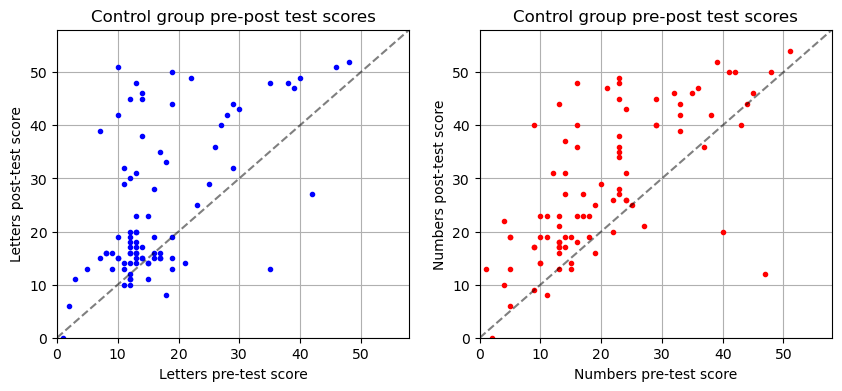

In [20]:
fig, axs = pyplot.subplots(nrows=1, ncols=2, figsize=(10, 4))

axs[0].plot(sesame_ctrl_df['prelet'], sesame_ctrl_df['postlet'], 'b.')
axs[0].set_xlabel('Letters pre-test score')
axs[0].set_ylabel('Letters post-test score')

axs[1].plot(sesame_ctrl_df['prenumb'], sesame_ctrl_df['postnumb'], 'r.')
axs[1].set_xlabel('Numbers pre-test score')
axs[1].set_ylabel('Numbers post-test score')

for ax in axs:
    ax.grid()
    ax.set_title('Control group pre-post test scores')
    ax.set_xlim(0, 58)
    ax.set_ylim(0, 58)
    ax.set_axisbelow(True)
    ax.plot([0, 58], [0, 58], 'k--', alpha=0.5)

### 18.8, Evaluating an encouragement design

> Return to the Sesame Street example from the previous exercise. Did
> encouragement (the variable viewenc) lead to an increase in post-test scores
> for letters (`postlet`) and numbers (`postnumb`)?  Fit an appropriate model to
> address this question.

In [21]:
# Generically useful pre-treatment predictors:
preds = [
    'encour',
    'regular',
    'sex',
    'age',
    'viewcat',
    'setting',
    'prelet',
    'prenumb',
    'peabody',
]
preds_formula = ' + '.join(preds)

In [22]:
# For letters:
letter_formula = f'postlet ~ {preds_formula}'
letter_model = bambi.Model(letter_formula, sesame_df)
letter_fit = letter_model.fit()
print(bg_ros.bambi_markdown(letter_fit, preds))

Initializing NUTS using jitter+adapt_diag...
/home/bgawalt/miniconda3/envs/ros_conda/lib/python3.14/site-packages/pytensor/link/c/cmodule.py:3004: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, encour, regular, sex, age, viewcat, setting, prelet, prenumb, peabody]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 9 seconds.


Coef.     | Mean   | s.e.
--------- | ------ | ------
sigma     | 9.23 | 0.43
Intercept | -8.27 | 6.30
encour    | 1.17 | 1.45
regular   | 1.95 | 2.37
sex       | 1.06 | 1.19
age       | 0.01 | 0.11
viewcat   | 3.69 | 0.85
setting   | 1.76 | 1.34
prelet    | 0.44 | 0.10
prenumb   | 0.25 | 0.10
peabody   | 0.14 | 0.05



In [23]:
print(letter_formula)

postlet ~ encour + regular + sex + age + viewcat + setting + prelet + prenumb + peabody


In [24]:
# For numbers:
number_formula = f'postnumb ~ {preds_formula}'
number_model = bambi.Model(number_formula, sesame_df)
number_fit = number_model.fit()
print(bg_ros.bambi_markdown(number_fit, preds))

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, encour, regular, sex, age, viewcat, setting, prelet, prenumb, peabody]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 9 seconds.


Coef.     | Mean   | s.e.
--------- | ------ | ------
sigma     | 8.81 | 0.41
Intercept | -7.45 | 5.90
encour    | 0.46 | 1.37
regular   | 2.40 | 2.18
sex       | 0.79 | 1.15
age       | 0.15 | 0.10
viewcat   | 2.46 | 0.80
setting   | 1.84 | 1.22
prelet    | 0.09 | 0.10
prenumb   | 0.52 | 0.09
peabody   | 0.11 | 0.04



In [25]:
print(number_formula)

postnumb ~ encour + regular + sex + age + viewcat + setting + prelet + prenumb + peabody


## 18.12, Simulating potential outcomes

> In this exercise, you will simulate an intervention study with a
> pre-determined average treatment effect.  The goal is for you to understand 
> the potential outcome framework, and the properties of completely randomized
> experiments through simulation.
>
> The setting for our hypothetical study is a class in which students take two
> quizzes.  After quiz 1 but before quiz 2, the instructor randomly assigns half
> the class to attend an extra tutoring session.  The other half of the class
> does not receive any additional help.  Consider the half of the class that
> receives tutoring as the treated group.  The goal is to estimate the effect of
> the extra tutoring session on average test scores for the retake of quiz 1.
> Assume that the stable unit treatment value assumption is satisfied.

In [26]:
rng = prng_builder.new('18.12, Simulating potential outcomes')

### 18.12(a)

> (a) Simulating all observed and potentially observed data (omniscient mode).
>     For this section, you are omniscient and thus know the potential outcomes
>     for everyone.  Simulate a dataset consistent with the following
>     assumptions.
>
> > i. The average treatment effect on all the students, $\tau$, equals 5.
> >
> > ii. The population size, $N$, is 1000.
> >
> > iii. Scores on quiz 1 approximately follow a normal distribution with mean
> >     of 65 and standard deviation of 3.
> >
> > iv. The potential outcomes for quiz 2 should be linearly related to the
> >     pre-treatment quiz score. In particular they should take the form,
> >
> > $$y^0 = \beta_0 + \beta_1x + 0 + \epsilon^0,$$
> > $$y^1 = \beta_0 + \beta_1x + \tau + \epsilon^1,$$
> >
> > where the intercept $\beta_0 = 10$ and the slope $\beta_1 = 1.1$.  Draw the
> > errors $\epsilon^0$ and $\epsilon^1$ independently from normal distributions
> > with mean 0 and standard deviations 1.

In [27]:
tau = 5
n = 1000
xs = rng.normal(loc=65, scale=3, size=n)
y0s = 10 + 1.1 * xs + rng.normal(size=n)
y1s = 10 + 1.1 * xs + tau + rng.normal(size=n)

### 18.12(b)

> (b) Calculating and interpreting average treatment effects (omniscient mode).
>     Answer the following questions based on the data-generating process or
>     using your simulated data.
>
> > i. What is your interpretation of $\tau$?
> >
> > ii. Calculate the sample average treatment effect (SATE) for your simulated
> >     dataset.
> > 
> > iii. Why is SATE different from $\tau$?
> >
> > iv. How would you interpret the intercept in the data-generating process
> >     for $y^0$ and $y^1$?
> >
> > v. How would you interpret $\beta_1$?
> >
> > vi. Plot the response surface versus $x$. What does this plot reveal?

In [28]:
sate = numpy.mean(y1s - y0s)
print(f'{sate:0.2f}')

5.08


Text(0.5, 1.0, 'Response surface')

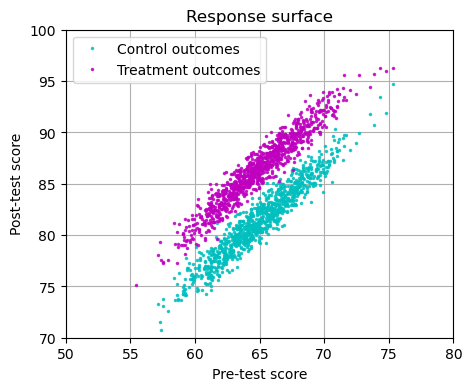

In [29]:
fig = pyplot.figure(figsize=(5, 4))
ax = fig.gca()
ax.plot(xs, y0s, 'c.', alpha=0.8, markersize=3, label='Control outcomes')
ax.plot(xs, y1s, 'm.', alpha=0.8, markersize=3, label='Treatment outcomes')
ax.grid()
ax.set_xlim(50, 80)
ax.set_ylim(70, 100)
ax.set_xlabel('Pre-test score')
ax.set_ylabel('Post-test score')
ax.legend()
ax.set_title('Response surface')

### 18.12(c)

> (c) Random assignment (researcher mode).  For the remaining parts of this
>     exercise, you are a mere researcher!  Return your goggle of omniscience
>     and use only the observed data available to the researcher; that is, you
>     do not have access to the counterfactual outcomes for each student.
>     Using the same simulated dataset generated above, randomly assign students 
>     to treatment and control groups. Then, create the observed dataset, which
>     will include pre-treatment scores, treatment assignment, and observed $y$.

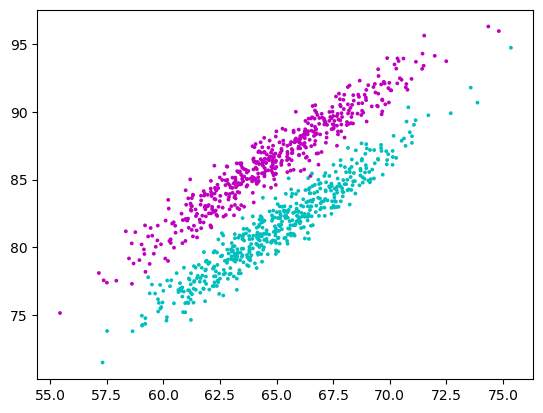

In [30]:
treat_ids = set(rng.choice(n, size=(n // 2), replace=False))
zs = numpy.array([1 if i in treat_ids else 0 for i in range(n)])
ys = (1 - zs) * y0s + zs * y1s
sim_df = pandas.DataFrame(data={
    'x': xs,
    'y': ys,
    'z': zs,
})
fig = pyplot.figure()
ax = fig.gca()
cs = ['c' if zi == 0 else 'm' for zi in zs]
ax.scatter(xs, ys, color=cs, s=3)

### 18.12(d)

> (d) Difference in means (researcher mode).
>
> > i. Estimate SATE using a difference in means.
> >
> > ii. Is this estimate close to the true SATE?  Divide the difference between
> >     SATE and estimated SATE by the standard deviation of the observed
> >     outcome, $y$.
> >
> > iii. Why is $\hat{\text{SATE}}$ different from SATE and $\tau$?

In [31]:
sate_hat = (
    numpy.mean([yi for (zi, yi) in zip(zs, ys) if zi == 1]) -
    numpy.mean([yi for (zi, yi) in zip(zs, ys) if zi == 0])
)
print(f'Est. SATE: {sate_hat:0.1f}')
print(f'Actual SAGE: {sate: 0.1f}')
print(f'[Act. SATE - Est. SATE] / S_y: {(sate - sate_hat) / ys.std():0.2f}')

Est. SATE: 5.0
Actual SAGE:  5.1
[Act. SATE - Est. SATE] / S_y: 0.03


### 18.12(e)

> (e) Researcher view: linear regression.
>
> > i. Now you will use linear regression to estimate SATE for the observed data
> >     created as above.  With this setup, you will begin to better understand
> >     some fundamental assumptions crucial for the R homework assignments in
> >     the following chapters.
> >
> > ii. What is gained by estimating the average treatment effect using linear
> >     regression instead of the mean difference estimate from above?
> >
> > iii. What assumptions do we need to make in order to believe this estimate?
> >     Given how you generated the data, do you believe these assumptions have
> >     been satisfied?

In [32]:
sim_model = bambi.Model('y ~ x + z', sim_df)
sim_fit = sim_model.fit()
print(bg_ros.bambi_markdown(sim_fit, ['x', 'z']))

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, x, z]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 8 seconds.


Coef.     | Mean   | s.e.
--------- | ------ | ------
sigma     | 1.00 | 0.02
Intercept | 8.76 | 0.69
x         | 1.12 | 0.01
z         | 5.10 | 0.06



## 18.13, Varying treatment effect

> Now you will explore a situation where treatment effect varies by a known
> covariate.
>
> (a) Simulate data from the following response surface and plot both curves,
>
>  $$y^0 = \beta_0^0 + \beta_1^0x + \epsilon^0,$$
>  $$y^1 = \beta_0^1 + \beta_1^1x + \epsilon^1,$$
>
>  where $\beta_0^0 = 35$, $\beta_1^0 = 0.6$, $\beta_0^1 = 15$,
>     $\beta_1^1 = 1$, and $\epsilon^0$ and $\epsilon^1$ are drawn independently
>     from normal distributions with mean 0 and standard deviation 1.
>
> (b) Comment on your findings. In particular, there is no longer a $\tau$
>     included in the data-generating process. Is there still a sample average
>     treatment effect? What is it? How do you interpret the average treatment
>     effect in this setting?
>
> (c) Is the treatment effect the same for all students? If not, is there a
>     pattern to the way it varies?  Why should you care about variation in the
>     treatment effect?
>
> (d) Plot the response surface versus $x$. What does this plot reveal,
>     particularly as compared to the plot from the previous question?

In [33]:
rng = prng_builder.new('Exercise 18.13, Varying treatment effect')

In [34]:
n = 1000
xs = rng.normal(loc=65, scale=3, size=n)
y0s = 35 + 0.6 * xs + rng.normal(size=n)
y1s = 15 + 1 * xs + rng.normal(size=n)

Text(0.5, 1.0, 'Response surface')

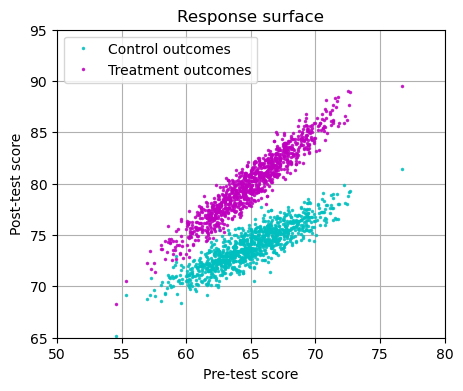

In [35]:
fig = pyplot.figure(figsize=(5, 4))
ax = fig.gca()
ax.plot(xs, y0s, 'c.', alpha=0.8, markersize=3, label='Control outcomes')
ax.plot(xs, y1s, 'm.', alpha=0.8, markersize=3, label='Treatment outcomes')
ax.grid()
ax.set_xlim(50, 80)
ax.set_ylim(65, 95)
ax.set_xlabel('Pre-test score')
ax.set_ylabel('Post-test score')
ax.legend(loc='upper left')
ax.set_title('Response surface')

In [36]:
sate = numpy.mean(y1s - y0s)
print(f'{sate:0.2f}')

6.11


## 18.14, Completely randomized experiment

> In a completely randomized experiment, the number of treatment and control
> units is decided in advance, and each unit has the same probability of being
> assigned to receive the treatment.  This exercise extends Exercise 18.12 by
> comparing the same estimates with respect to both bias and efficiency.
>
> You will operationalize these properties by appealing to randomization-based
> inference.  Therefore you will create a randomization distribution (similar to
> a sampling distribution) for each estimate.  This distribution only considers
> the variability in estimates that would manifest as a result of the randomness
> in who is assigned to receive the treatment.
>
> (a) Simulate the dataset from Exercise 18.12.  You will use this as your
>     observed data.
>
> (b) Now create a randomization distribution for each estimate by following
>     these steps:
>
> > i. Create a vector of length 10,000 for each estimate to save these
> >     estimates across simulated datasets. These could be named, for instance,
> >     `dm_res` and `ols_res`.
> >
> > ii. For the $r^{\text{th}}$ simulated draw, generate a new treatment
> >     assignment vector using the `rbinom()` or `sample()` function in R.
> >     Use it to generate a new outcome vector, recalling that
> >     $y = (1 - z) y^0 + z y^1$.
> >
> > iii. Apply each of the estimates (difference in means and linear regression
> >     with the one covariate) to the newly generated dataset. Save each
> >     estimate as the rth item in the results vector.
> >
> > iv. Repeat 10 000 times.
>
> (c) We will use these estimates to create a Monte Carlo estimate of a
>     randomization distribution for each of these estimates for the sample
>     average treatment effect.
>
> (d) Plot the randomization distribution for each of the two estimates:
>     difference in means and regression.  Either overlay the plots (with
>     different colors for each) or make sure the x-axis range on both plots is
>     the same. Also add vertical lines (using different colors) for the SATE
>     and the mean of the randomization distribution.
>
> (e) Use these distributions to calculate the bias of each of these two
>     methods.  What is the difference between methods with respect to bias?
>
> (f) Use these distributions to calculate the efficiency of each of these two
>     methods. What is the difference between methods with respect to
>     efficiency?
>
> (g) Re-run the simulation by first generating data as in Exercise 18.12 but
>     with a zero coefficient for the pre-treatment score. Does the zero
>     coefficient lead to a different bias and efficiency estimate compared to
>     when the coefficient for pre-treatment score was at 1.1 from before?

In [37]:
rng = prng_builder.new('18.14, Completely randomized experiment')

In [38]:
num_sims = 1

In [39]:
tau = 5
n = 1000
xs = rng.normal(loc=65, scale=3, size=n)
y0s = 10 + 0 * xs + rng.normal(size=n)
y1s = 10 + 0 * xs + tau + rng.normal(size=n)

In [40]:
sate = numpy.mean(y1s - y0s)
print(f'{sate: 0.2f}')

 4.99


In [41]:
def estimate_treatment_effect() -> (float, float):
    """Returns mean-diff and regression-based treatment effects."""
    zs = rng.choice(2, size=n)
    ys = (1 - zs) * y0s + zs * y1s

    sate_hat = (
        numpy.mean([yi for yi, zi in zip(ys, zs) if zi == 1]) -
        numpy.mean([yi for yi, zi in zip(ys, zs) if zi == 0])
    )
    
    df = pandas.DataFrame(data={'x': xs, 'y': ys, 'z': zs})
    model = bambi.Model('y ~ x + z', df)
    fit = model.fit()
    tau = arviz.summary(fit)['mean']['z']

    return(sate_hat, tau)

In [42]:
sims = [estimate_treatment_effect() for _ in range(num_sims)]

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, x, z]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 8 seconds.


In [43]:
dm_res = [dm for dm, _ in sims]
ols_res = [ols for _, ols in sims]
print(max(dm_res), numpy.mean(dm_res), min(dm_res))
print(max(ols_res), numpy.mean(ols_res), min(ols_res))
print(sate)

5.0229598798702195 5.0229598798702195 5.0229598798702195
5.022 5.022 5.022
4.985882226722908


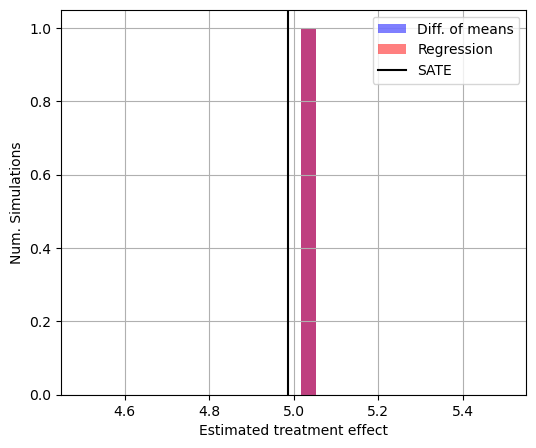

In [44]:
fig = pyplot.figure(figsize=(6, 5))
ax = fig.gca()
ax.hist(dm_res, bins=numpy.linspace(4.5, 5.5, 30), color='b', alpha=0.5, label='Diff. of means')
ax.hist(ols_res, bins=numpy.linspace(4.5, 5.5, 30), color='r', alpha=0.5, label='Regression')
ax.axvline(x=sate, color='k', label='SATE')
ax.set_xlabel('Estimated treatment effect')
ax.set_ylabel('Num. Simulations')
ax.legend()
ax.grid()

## 18.15, Randomized block design with interactions

> In a randomized block design, randomization occurs separately within blocks,
> and the ratio of treatment to control observations is allowed to vary across
> blocks.  And, as always, the underlying treatment effect can vary across
> blocks.
>
> For this exercise, you will simulate datasets for a randomized block design
> that includes sex as a blocking variable.  You will then estimate the average
> treatment with two estimates: one that accounts for the blocking structure and
> one that does not.  You will compare the bias and efficiency of these
> estimates. We will walk you through this in steps.
> 
> (a) First simulate the blocking variable and potential outcomes. In
>     particular:
> 
> *  Generate sex as a blocking variable, with 30% female and 70% male.
> *  Generate y0 and y1 with the following features:
>    *  The intercept of the regression of y on treatment indicator, block
>          indicator, and their interaction, is 70.
>    *  The residual standard deviation is 1.
>    *  Treatment effect varies by block: the average treatment effect is 7 for
>          women and 3 for men. Further assume that men and women have no average
>          difference under the control.

In [57]:
rng = prng_builder.new('Exercise 18.15, Randomized block design with interactions')

In [58]:
n = 150
# x_i is 1 if subject i is male
xs = rng.binomial(1, 0.7, size=n)
y0s = 70 + rng.normal(size=n)
y1s = 70 + 7 - 4 * xs + rng.normal(size=n)

### 18.15(b)

> (b) Calculate the sample average treatment effect (SATE) overall and for each
>     block.

In [59]:
sate = numpy.mean(y1s - y0s)
sate_men = (
    numpy.mean([yi for xi, yi in zip(xs, y1s) if xi == 1]) - 
    numpy.mean([yi for xi, yi in zip(xs, y0s) if xi == 1])
)
sate_women = (
    numpy.mean([yi for xi, yi in zip(xs, y1s) if xi == 0]) - 
    numpy.mean([yi for xi, yi in zip(xs, y0s) if xi == 0])
)
print(f'*  SATE: {sate:0.2f}')
print(f'*  SATE for men: {sate_men:0.2f}')
print(f'*  SATE for women: {sate_women:0.2f}')

*  SATE: 3.82
*  SATE for men: 2.74
*  SATE for women: 6.89


### 18.15(c) and (d)

> (c) Now create a function for assigning the treatment.  In particular, within
>     each block create different assignment probabilities:
>
>  $$\text{Pr}(z = 1 | \text{male}) = 0.6,$$
>  $$\text{Pr}(z = 1 | \text{female}) = 0.4.$$
>
> (d) Generate the treatment and create a vector for the observed outcomes
>     implied by that treatment.  We will use this to create a randomization
>     distribution for two different estimates for the SATE. Take 100,000 draws
>     from that distribution.

In [60]:
num_sims = 3
def estimate_treatment_effect() -> (float, float):
    """Returns mean-diff and regression-based treatment effects."""
    zs = rng.binomial(1, 0.4 + 0.2 * xs, size=n)
    ys = (1 - zs) * y0s + zs * y1s

    sate_hat = (
        numpy.mean([yi for yi, zi in zip(ys, zs) if zi == 1]) -
        numpy.mean([yi for yi, zi in zip(ys, zs) if zi == 0])
    )
    
    df = pandas.DataFrame(data={'x': xs, 'y': ys, 'z': zs})
    model = bambi.Model('y ~ x + z', df)
    fit = model.fit()
    tau = arviz.summary(fit)['mean']['z']

    return(sate_hat, tau)

sims = [estimate_treatment_effect() for _ in range(num_sims)]

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, x, z]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 9 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, x, z]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 8 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, x, z]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 8 seconds.


In [61]:
dm_res = [dm for dm, _ in sims]
ols_res = [ols for _, ols in sims]
print(max(dm_res), numpy.mean(dm_res), min(dm_res))
print(max(ols_res), numpy.mean(ols_res), min(ols_res))
print(sate)

3.6272215185194057 3.4779223088977034 3.3462046632827054
3.943 3.812666666666667 3.634
3.8177535946284666


### 18.15(e)

> (e) Plot the Monte Carlo estimate of the randomization distribution for each
>     of the two estimates: difference in means and regression.  Either overlay
>     the plots (with different colors for each) or make sure the x-axis on both
>     plots is the same.

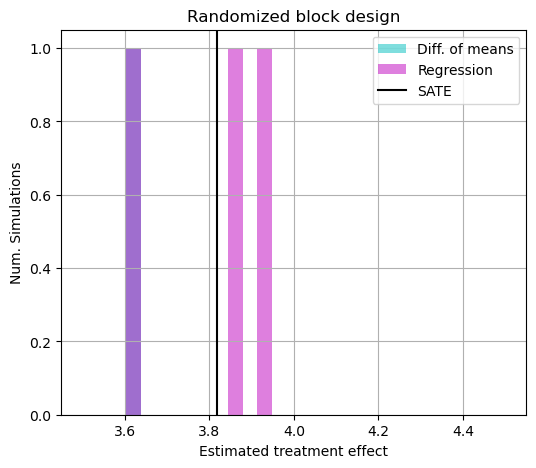

In [62]:
fig = pyplot.figure(figsize=(6, 5))
ax = fig.gca()
ax.hist(dm_res, bins=numpy.linspace(3.5, 4.5, 30), color='c', alpha=0.5, label='Diff. of means')
ax.hist(ols_res, bins=numpy.linspace(3.5, 4.5, 30), color='m', alpha=0.5, label='Regression')
ax.axvline(x=sate, color='k', label='SATE')
ax.set_xlabel('Estimated treatment effect')
ax.set_ylabel('Num. Simulations')
ax.set_title('Randomized block design')
ax.legend()
ax.grid()

### 18.15(f)

> (f) Calculate the bias and efficiency of each estimate.  Also calculate the
>     root mean squared error.

In [63]:
print(numpy.mean(dm_res))
print(numpy.std(dm_res))
print(numpy.mean(ols_res))
print(numpy.std(ols_res))


3.4779223088977034
0.1153962789015097
3.812666666666667
0.13069642518277072


### 18.15(i)

> (i) How could you use a regression to estimate the treatment effects
>     separately by group?  Calculate estimates for our original sample and
>     treatment assignment.

In [64]:
zs = rng.binomial(1, 0.4 + 0.2 * xs, size=n)
ys = (1 - zs) * y0s + zs * y1s

df = pandas.DataFrame(data={'x': xs, 'y': ys, 'z': zs})
model = bambi.Model('y ~ x + z + x:z', df)
fit = model.fit()
print(bg_ros.bambi_markdown(fit, ['x', 'z', 'x:z']))

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, x, z, x:z]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 8 seconds.


Coef.     | Mean   | s.e.
--------- | ------ | ------
sigma     | 1.01 | 0.06
Intercept | 70.09 | 0.19
x         | 0.03 | 0.25
z         | 6.56 | 0.36
x:z       | -3.87 | 0.41

